# Data Mining Assignment: Naive Bayes vs Logistic Regression

In [2]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
# load the csv and preview it
df = pd.read_csv("diabetes.csv")
print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# check column types, missing values, and summary stats
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64


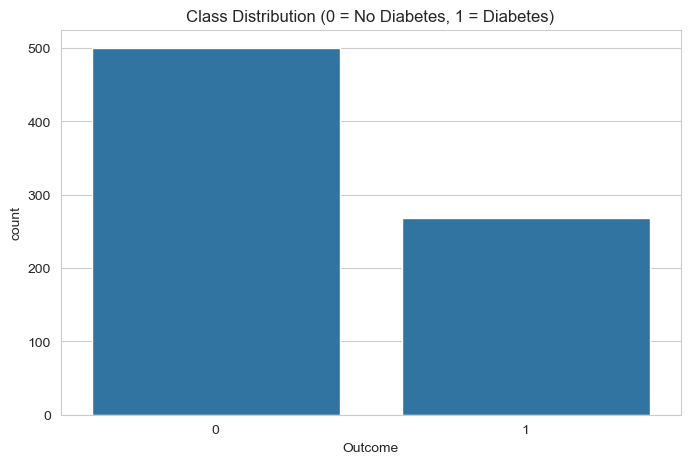

In [5]:
# check class balance and plot it
print(df["Outcome"].value_counts())
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.show()


In [6]:
# columns where 0 is not a realistic value
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print((df[zero_as_missing] == 0).sum())


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [7]:
# replace those 0s with NaN, then fill with the column median
df_clean = df.copy()
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)
df_clean[zero_as_missing] = df_clean[zero_as_missing].fillna(df_clean[zero_as_missing].median())
df_clean.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


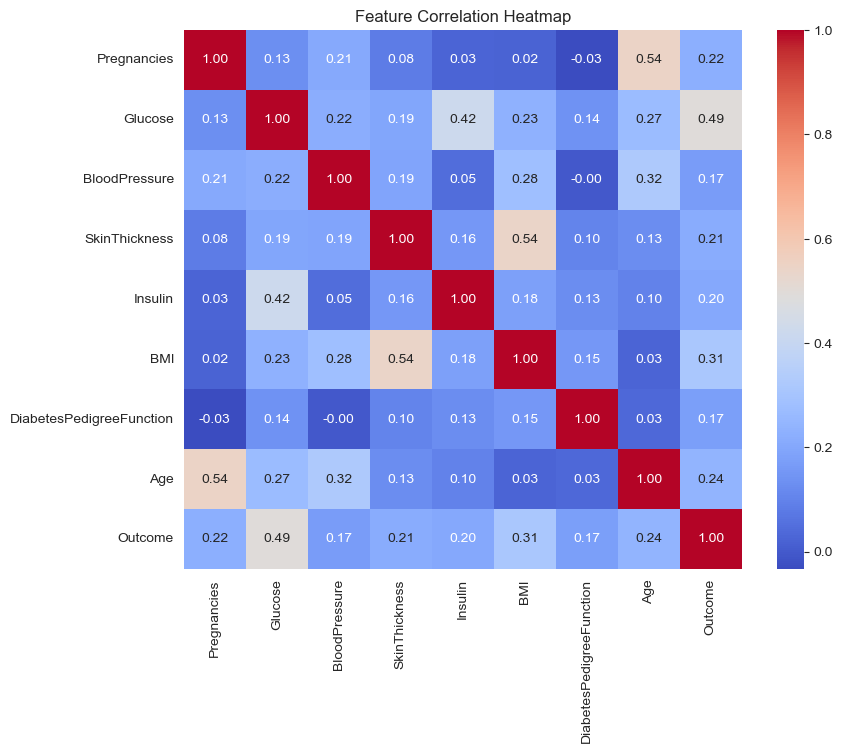

In [8]:
# correlation heatmap between features
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [9]:
# separate features and target, then split into train and test sets
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale features so they are on a similar range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (614, 8)  Test shape: (154, 8)


## 5. Model 1 — Naive Bayes

Naive Bayes assumes features are independent of each other given the class.


In [10]:
# train the model and predict on the test set
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]


In [11]:
# print evaluation metrics
print("Accuracy: ", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:   ", recall_score(y_test, y_pred_nb))
print("F1 score: ", f1_score(y_test, y_pred_nb))
print()
print(classification_report(y_test, y_pred_nb))


Accuracy:  0.7012987012987013
Precision: 0.5666666666666667
Recall:    0.6296296296296297
F1 score:  0.5964912280701754

              precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



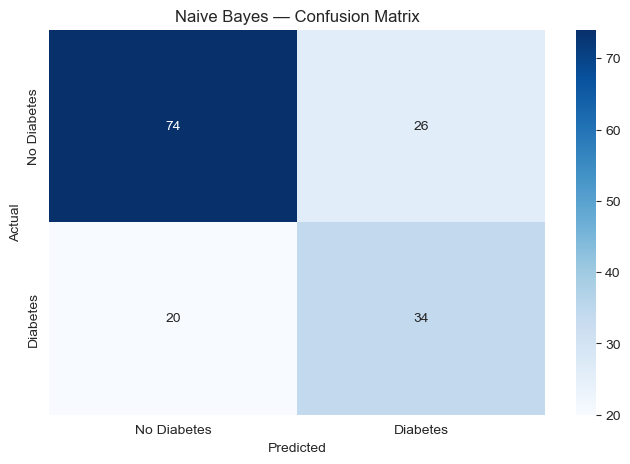

In [12]:
# confusion matrix as a heatmap
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Naive Bayes — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


## 6. Model 2 — Logistic Regression

In [13]:
# train the model and predict on the test set
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]


In [14]:
# print evaluation metrics
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:   ", recall_score(y_test, y_pred_lr))
print("F1 score: ", f1_score(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))


Accuracy:  0.7077922077922078
Precision: 0.6
Recall:    0.5
F1 score:  0.5454545454545454

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



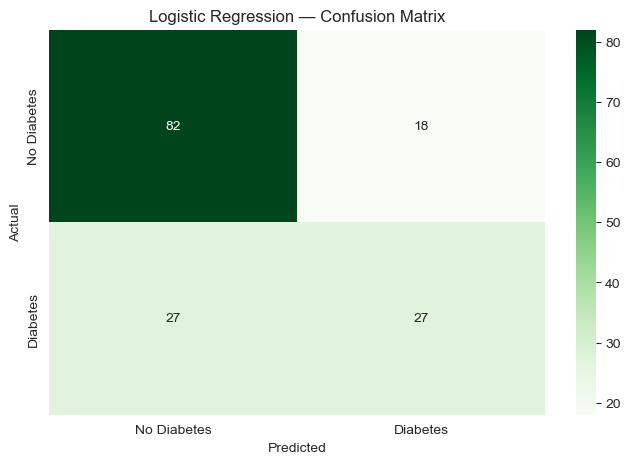

In [15]:
# confusion matrix as a heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Logistic Regression — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


C:\Users\l.mbabazi\AppData\Local\Temp\ipykernel_29292\1093338152.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")


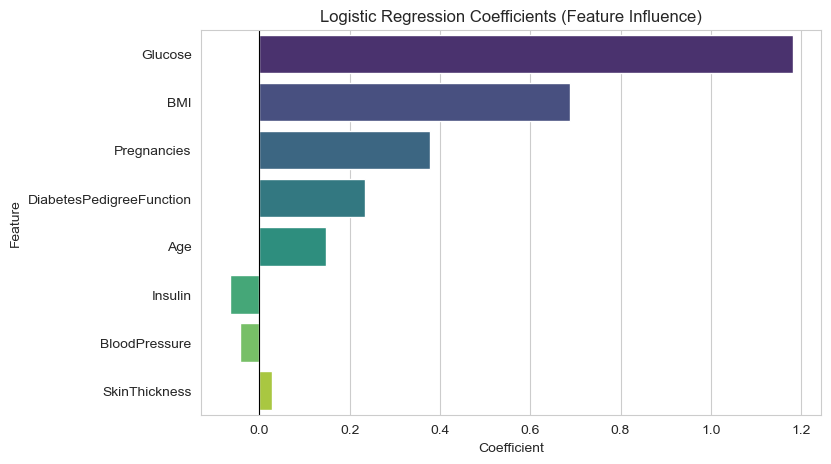

,Feature,Coefficient
1,Glucose,1.182511
5,BMI,0.688735
0,Pregnancies,0.377502
6,DiabetesPedigreeFunction,0.233386
7,Age,0.147798
4,Insulin,-0.066157
2,BloodPressure,-0.044066
3,SkinThickness,0.028225


In [16]:
# see which features influence the prediction most
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")
plt.title("Logistic Regression Coefficients (Feature Influence)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

coef_df


## 7. Model Comparison

In [17]:
# put both models' scores into one table
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_lr)],
    "Precision": [precision_score(y_test, y_pred_nb), precision_score(y_test, y_pred_lr)],
    "Recall": [recall_score(y_test, y_pred_nb), recall_score(y_test, y_pred_lr)],
    "F1 Score": [f1_score(y_test, y_pred_nb), f1_score(y_test, y_pred_lr)],
    "ROC AUC": [roc_auc_score(y_test, y_proba_nb), roc_auc_score(y_test, y_proba_lr)],
})
results


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.701299,0.566667,0.62963,0.596491,0.764630
1,Logistic Regression,0.707792,0.600000,0.50000,0.545455,0.812963


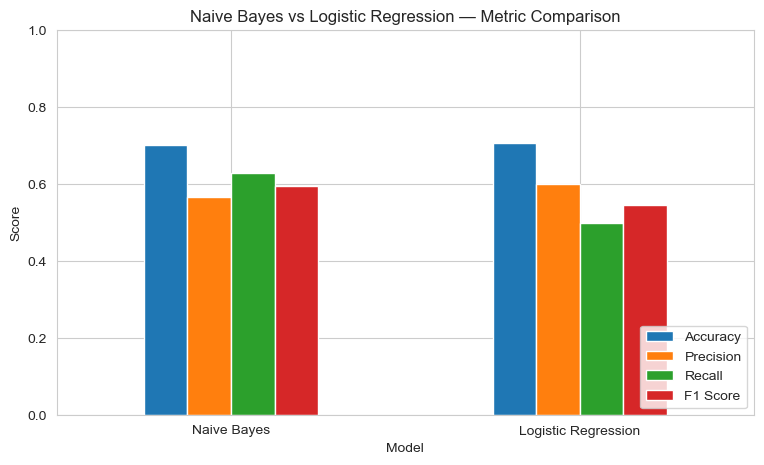

In [18]:
# bar chart comparing the two models
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(9, 5), rot=0
)
plt.title("Naive Bayes vs Logistic Regression — Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


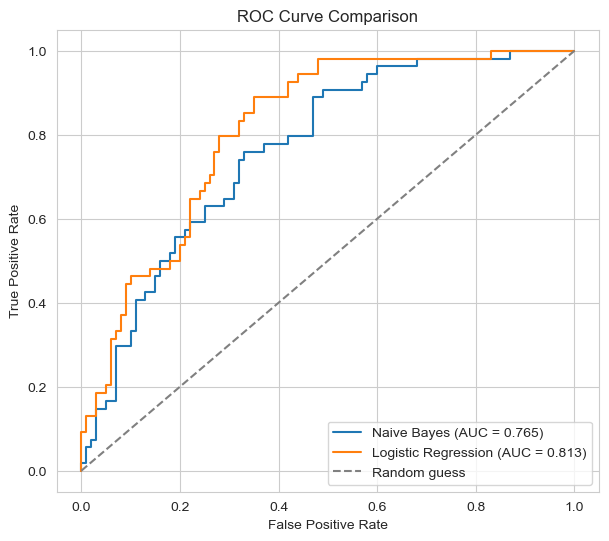

In [19]:
# ROC curves for both models
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {roc_auc_score(y_test, y_proba_nb):.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## 8. Conclusion

- Both models were trained on the same data and tested on the same held-out set.
- The table and charts above compare Accuracy, Precision, Recall, F1, and ROC AUC.
- Naive Bayes is simple and fast, but assumes features are independent (not fully true here).
- Logistic Regression can handle correlated features better and gives interpretable coefficients.
